# 🎓 Classroom Abnormal Behavior Recognition — Phase 1: CNN Image Classification

**Model**: MobileNetV2 (Transfer Learning + Fine-Tuning)  
**Framework**: TensorFlow / Keras  
**Dataset**: 5 classes × 300 images = 1500 images total  

### Classes
| # | Class | Description |
|---|-------|-------------|
| 0 | `eye_movement` | Student looking around |
| 1 | `hand_move` | Student raising / moving hand |
| 2 | `mobile_use` | Student using phone |
| 3 | `mouth_open` | Student talking / yawning |
| 4 | `side_watching` | Student looking sideways |

## 📁 Step 1 — Mount Google Drive

All dataset paths and saved models will reference your Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Step 2 — Install & Import Libraries

All required libraries come pre-installed on Colab. We import everything upfront so dependency errors surface immediately.

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing import image as keras_image

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## ⚙️ Step 3 — Configuration

All hyper-parameters are defined **once** here.  
Change only this cell to experiment.

| Parameter | Value | Reason |
|-----------|-------|--------|
| IMG_SIZE | 224×224 | MobileNetV2 native input |
| BATCH_SIZE | 16 | Small dataset — smaller batch = more gradient updates |
| EPOCHS_FROZEN | 30 | Phase 1: train head only |
| EPOCHS_FINETUNE | 20 | Phase 2: unfreeze top layers |
| LR_FROZEN | 1e-3 | Standard Adam for head training |
| LR_FINETUNE | 1e-5 | Very low LR for fine-tuning to avoid catastrophic forgetting |
| UNFREEZE_FROM | -30 | Unfreeze last 30 layers of backbone |

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = '/content/drive/MyDrive/DeepLearningProject/dataset'
TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'validation')
TEST_DIR    = os.path.join(BASE_DIR, 'test')
SAVE_DIR    = '/content/drive/MyDrive/DeepLearningProject/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Image / training config ───────────────────────────────────────────────────
IMG_SIZE       = (224, 224)
IMG_SHAPE      = (224, 224, 3)
BATCH_SIZE     = 16          # smaller batch → better generalisation on tiny data
EPOCHS_FROZEN  = 30          # Phase 1: backbone frozen
EPOCHS_FINETUNE = 20         # Phase 2: top layers unfrozen
LR_FROZEN      = 1e-3
LR_FINETUNE    = 1e-5        # must be very low for fine-tuning
UNFREEZE_FROM  = -30         # unfreeze last N layers of backbone
NUM_CLASSES    = 5
DROPOUT_RATE   = 0.4

print('Configuration ready.')
print(f'  Train dir : {TRAIN_DIR}')
print(f'  Val dir   : {VAL_DIR}')
print(f'  Test dir  : {TEST_DIR}')
print(f'  Save dir  : {SAVE_DIR}')

Configuration ready.
  Train dir : /content/drive/MyDrive/DeepLearningProject/dataset/train
  Val dir   : /content/drive/MyDrive/DeepLearningProject/dataset/validation
  Test dir  : /content/drive/MyDrive/DeepLearningProject/dataset/test
  Save dir  : /content/drive/MyDrive/DeepLearningProject/saved_models


## 📂 Step 4 — Load Datasets

**Important design decisions:**
- Augmentation is applied **only to training data**, never to val/test.
- Normalization (`/255`) is placed **inside the model** via `Rescaling`.  
  This guarantees the **exact same preprocessing** whether training or predicting —  
  eliminating the classic double-normalization bug.
- Class names are extracted from the folder structure — never hardcoded.

In [4]:
# ── Load raw datasets (pixel values 0-255, no normalization yet) ─────────────
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ── Class names — auto-detected from folder names ─────────────────────────────
CLASS_NAMES = train_ds_raw.class_names
print(f'Detected {len(CLASS_NAMES)} classes: {CLASS_NAMES}')

# Save class names so prediction cell never needs to hardcode them
with open(os.path.join(SAVE_DIR, 'class_names.json'), 'w') as f:
    json.dump(CLASS_NAMES, f)
print('class_names.json saved to Drive.')

Found 1200 files belonging to 5 classes.
Found 150 files belonging to 5 classes.
Found 150 files belonging to 5 classes.
Detected 5 classes: ['eye_movement', 'hand_move', 'mobile_use', 'mouth_open', 'side_watching']
class_names.json saved to Drive.


## 📊 Step 5 — Dataset Statistics

Check class distribution to detect class imbalance before training.

In [5]:
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])
            counts[cls] = n
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

print(f'{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}')
print('-' * 52)
for cls in CLASS_NAMES:
    tr = train_counts.get(cls, 0)
    vl = val_counts.get(cls, 0)
    ts = test_counts.get(cls, 0)
    print(f'{cls:<20} {tr:>8} {vl:>8} {ts:>8} {tr+vl+ts:>8}')
print('-' * 52)
total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())
print(f'{'TOTAL':<20} {total_train:>8} {total_val:>8} {total_test:>8} {total_train+total_val+total_test:>8}')

Class                   Train      Val     Test    Total
----------------------------------------------------
eye_movement              240       30       30      300
hand_move                 240       30       30      300
mobile_use                240       30       30      300
mouth_open                240       30       30      300
side_watching             240       30       30      300
----------------------------------------------------
TOTAL                    1200      150      150     1500


## 🖼️ Step 6 — Visualize Sample Training Images

Always inspect raw data before training.  
Images are shown **before normalization** at full 0–255 range.

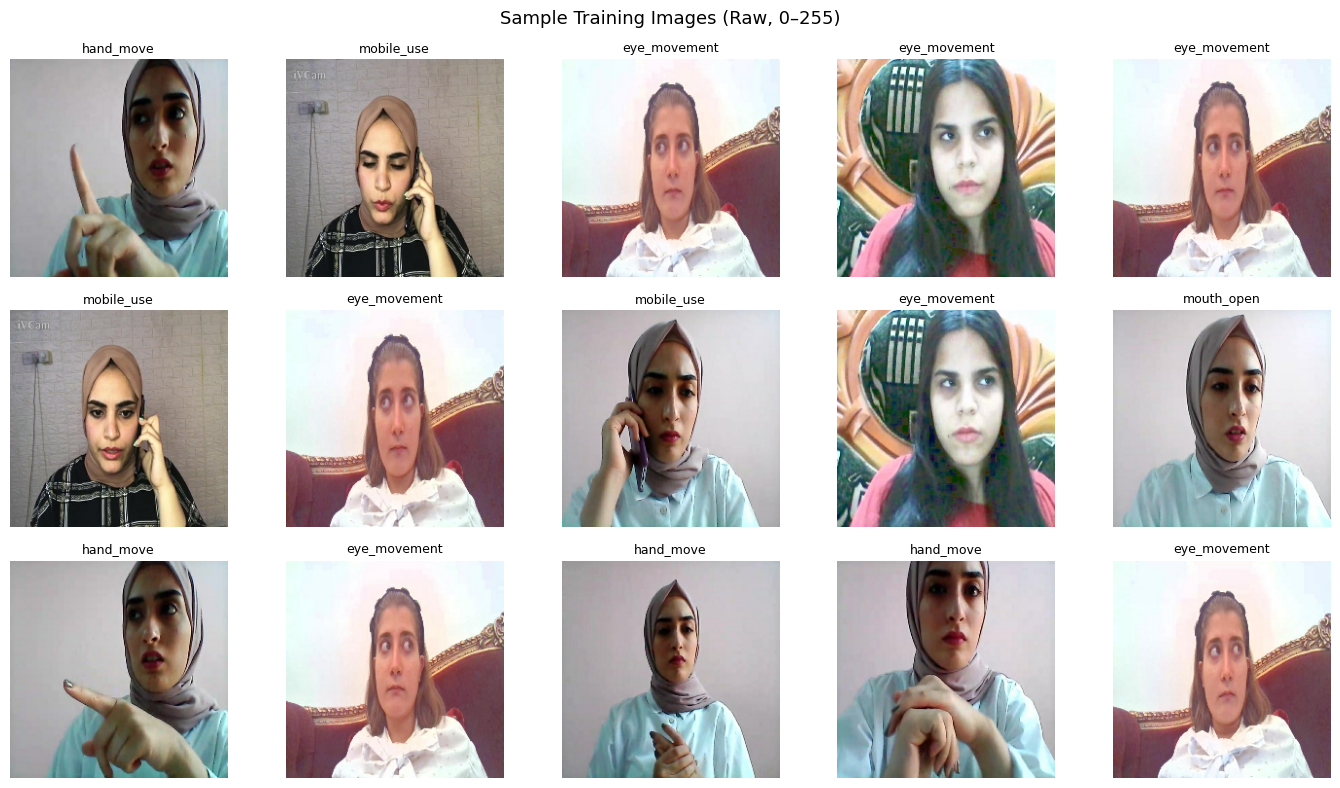

In [6]:
plt.figure(figsize=(14, 8))
for images, labels in train_ds_raw.take(1):
    for i in range(min(15, len(images))):
        ax = plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[labels[i]], fontsize=9)
        plt.axis('off')
plt.suptitle('Sample Training Images (Raw, 0–255)', fontsize=13)
plt.tight_layout()
plt.show()

## 🔀 Step 7 — Data Augmentation Pipeline

With only ~300 images per class, aggressive augmentation is **essential** to prevent overfitting.

| Augmentation | Range | Reason |
|---|---|---|
| RandomFlip | horizontal | Students face both directions |
| RandomRotation | ±15% | Slight camera angle variation |
| RandomZoom | ±15% | Distance from camera varies |
| RandomTranslation | ±10% | Subject not always centered |
| RandomContrast | 30% | Lighting in classrooms varies |
| RandomBrightness | 20% | Further lighting variation |

> Augmentation is applied **only during training**, never on val/test.

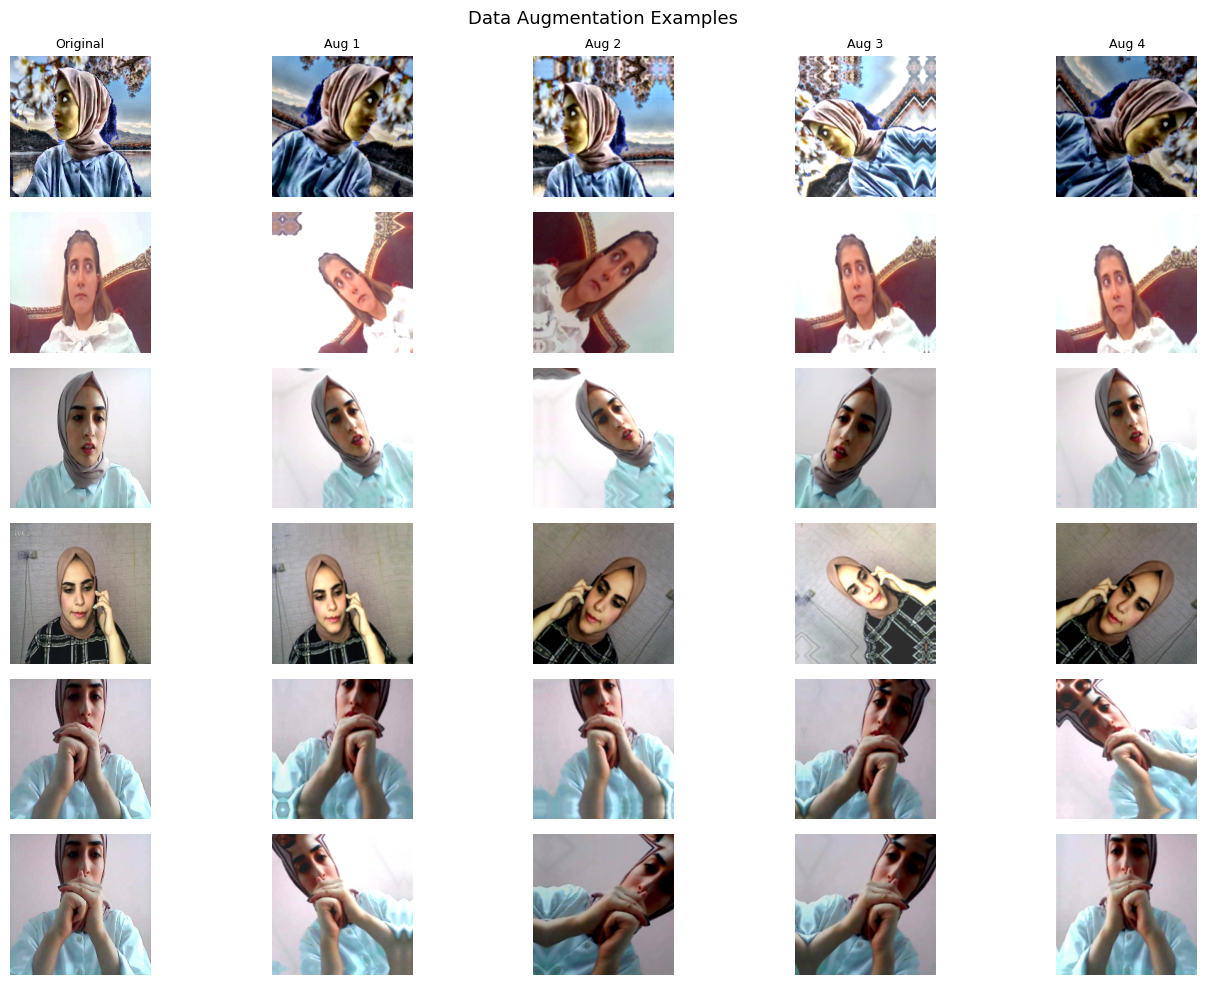

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.15, seed=SEED),
    layers.RandomZoom(0.15, seed=SEED),
    layers.RandomTranslation(0.10, 0.10, seed=SEED),
    layers.RandomContrast(0.30, seed=SEED),
    layers.RandomBrightness(0.20, seed=SEED),
], name='augmentation')

# ── Visualise augmented samples ───────────────────────────────────────────────
sample_batch = next(iter(train_ds_raw))
sample_images = sample_batch[0][:6]

plt.figure(figsize=(14, 10))
for row, img in enumerate(sample_images):
    # Original
    ax = plt.subplot(6, 5, row * 5 + 1)
    plt.imshow(img.numpy().astype('uint8'))
    if row == 0: plt.title('Original', fontsize=9)
    plt.axis('off')
    # 4 augmented versions
    for col in range(4):
        ax = plt.subplot(6, 5, row * 5 + col + 2)
        aug = data_augmentation(tf.expand_dims(img, 0), training=True)
        plt.imshow(tf.squeeze(aug).numpy().astype('uint8'))
        if row == 0: plt.title(f'Aug {col+1}', fontsize=9)
        plt.axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=13)
plt.tight_layout()
plt.show()

## ⚡ Step 8 — Build Optimized tf.data Pipeline

- Augmentation applied **only to train set** via `map()`
- `prefetch(AUTOTUNE)` overlaps CPU preprocessing with GPU training
- `cache()` on val/test — they are small enough to fit in RAM

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Apply augmentation to training data only ─────────────────────────────────
def augment_train(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_ds_raw
    .map(augment_train, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Val and test: no augmentation, just prefetch
val_ds  = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(AUTOTUNE)

print('tf.data pipelines ready.')
print(f'  train_ds: augmented + prefetched')
print(f'  val_ds  : cached + prefetched')
print(f'  test_ds : cached + prefetched')

tf.data pipelines ready.
  train_ds: augmented + prefetched
  val_ds  : cached + prefetched
  test_ds : cached + prefetched


## 🏗️ Step 9 — Build Model (MobileNetV2 + Custom Head)

**Architecture:**
```
Input (224×224×3, raw uint8)
  └─ Rescaling (0–255 → 0–1)        ← normalization lives HERE, inside the model
  └─ MobileNetV2 backbone (frozen)   ← ImageNet pre-trained features
  └─ GlobalAveragePooling2D
  └─ BatchNormalization
  └─ Dense(256, relu)
  └─ Dropout(0.4)
  └─ Dense(128, relu)
  └─ Dropout(0.3)
  └─ Dense(5, softmax)               ← 5-class output
```

**Why Rescaling inside the model?**  
When the model file is saved and reloaded, the preprocessing layer is part of the graph.  
You can pass raw images (0–255) at inference time — no manual `/255` needed.  
This eliminates the double-normalization bug in the original notebook.

In [9]:
def build_model(num_classes=NUM_CLASSES):
    # ── Input ────────────────────────────────────────────────────────────────
    inputs = keras.Input(shape=IMG_SHAPE, name='input_image')

    # ── Normalization (lives INSIDE model — safe for both train & predict) ───
    x = layers.Rescaling(1.0 / 255.0, name='rescaling')(inputs)

    # ── MobileNetV2 backbone (frozen during phase 1) ──────────────────────────
    backbone = MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False          # freeze all backbone layers
    x = backbone(x, training=False)     # training=False → BatchNorm uses stored stats

    # ── Custom head ──────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='head_bn')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout_1')(x)
    x = layers.Dense(128, activation='relu', name='dense_128')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs, outputs, name='MobileNetV2_Classroom'), backbone

model, backbone = build_model()
model.summary(line_length=90)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Classroom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)              │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                 │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)          │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_bn (BatchNormalization)          │ (None, 1280)                 │           5,120 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_256 (Dense)                     │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                     │ (None, 128)                  │          32,896 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                   │ (None, 128)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ output (Dense)                        │ (None, 5)                    │             645 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 🔔 Step 10 — Define Training Callbacks

| Callback | Purpose |
|---|---|
| `ModelCheckpoint` | Saves the best model (by val_loss) automatically |
| `EarlyStopping` | Stops training when val_loss stops improving (patience=8) |
| `ReduceLROnPlateau` | Halves the learning rate when val_loss plateaus |

> `restore_best_weights=True` in EarlyStopping ensures we end with the best checkpoint, not the last epoch.

In [10]:
CKPT_PATH = os.path.join(SAVE_DIR, 'best_model.keras')

checkpoint_cb = ModelCheckpoint(
    filepath=CKPT_PATH,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

callbacks_phase1 = [checkpoint_cb, early_stop_cb, reduce_lr_cb]
print('Callbacks defined.')

Callbacks defined.


## 🚀 Step 11 — Phase 1: Train with Frozen Backbone

In this phase, the MobileNetV2 backbone is **completely frozen**.  
Only the custom head layers (Dense, Dropout, BatchNorm) are trained.  

**Why this two-phase approach?**  
If we fine-tune all layers immediately with a large learning rate,  
the random head weights corrupt the pre-trained backbone features  
(known as *catastrophic forgetting*).  
Phase 1 stabilises the head first.

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FROZEN),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Phase 1 — Frozen backbone training')
print(f'Trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}')

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks_phase1,
    verbose=1
)

Phase 1 — Frozen backbone training
Trainable params: 364,037
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7486 - loss: 0.7648
Epoch 1: val_loss improved from None to 0.10571, saving model to /content/drive/MyDrive/DeepLearningProject/saved_models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepLearningProject/saved_models/best_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.8808 - loss: 0.3717 - val_accuracy: 1.0000 - val_loss: 0.1057 - learning_rate: 0.0010
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9493 - loss: 0.1668
Epoch 2: val_loss improved from 0.10571 to 0.06798, saving model to /content/drive/MyDrive/DeepLearningProject/saved_models/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DeepLearningProject/saved_models/best_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 79s 323ms/step - accuracy: 0.9492 - loss: 0.1691 - val_accuracy: 0.9667 - val_loss: 0.0680 - learning_rate: 

## 🔓 Step 12 — Phase 2: Fine-Tune Top Backbone Layers

Now we unfreeze the **last 30 layers** of MobileNetV2 and train with a  
very low learning rate (`1e-5`) to avoid destroying pre-trained weights.

> **Rule of thumb**: Fine-tune with a learning rate 10–100× smaller than Phase 1.

In [12]:
# ── Unfreeze last N layers of the backbone ───────────────────────────────────
backbone.trainable = True
for layer in backbone.layers[:UNFREEZE_FROM]:
    layer.trainable = False

# Count trainable vs frozen
trainable   = sum(1 for l in backbone.layers if l.trainable)
frozen      = sum(1 for l in backbone.layers if not l.trainable)
print(f'Backbone layers — trainable: {trainable}, frozen: {frozen}')

# Recompile with very low LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CKPT_PATH_FT = os.path.join(SAVE_DIR, 'best_model_finetuned.keras')
callbacks_phase2 = [
    ModelCheckpoint(CKPT_PATH_FT, monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)
]

print(f'Phase 2 — Fine-tuning top {abs(UNFREEZE_FROM)} backbone layers')
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks_phase2,
    verbose=1
)

Backbone layers — trainable: 30, frozen: 124
Phase 2 — Fine-tuning top 30 backbone layers
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8828 - loss: 0.3022
Epoch 1: val_loss improved from None to 0.25960, saving model to /content/drive/MyDrive/DeepLearningProject/saved_models/best_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepLearningProject/saved_models/best_model_finetuned.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 401ms/step - accuracy: 0.9100 - loss: 0.2658 - val_accuracy: 0.9333 - val_loss: 0.2596 - learning_rate: 1.0000e-05
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9352 - loss: 0.1817
Epoch 2: val_loss did not improve from 0.25960
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 280ms/step - accuracy: 0.9400 - loss: 0.1712 - val_accuracy: 0.9267 - val_loss: 0.3926 - learning_rate: 1.0000e-05
Epoch 3/20
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9429 - loss: 0.1429
Epoch 3: val_loss did not improve from 0.25960


## 📈 Step 13 — Training Curves (Both Phases Combined)

Plotting the full training history across both phases helps us visually diagnose:
- **Overfitting**: train accuracy >> val accuracy, val loss rising
- **Underfitting**: both train and val accuracy are low
- **Good fit**: train ≈ val, both high accuracy, both low loss

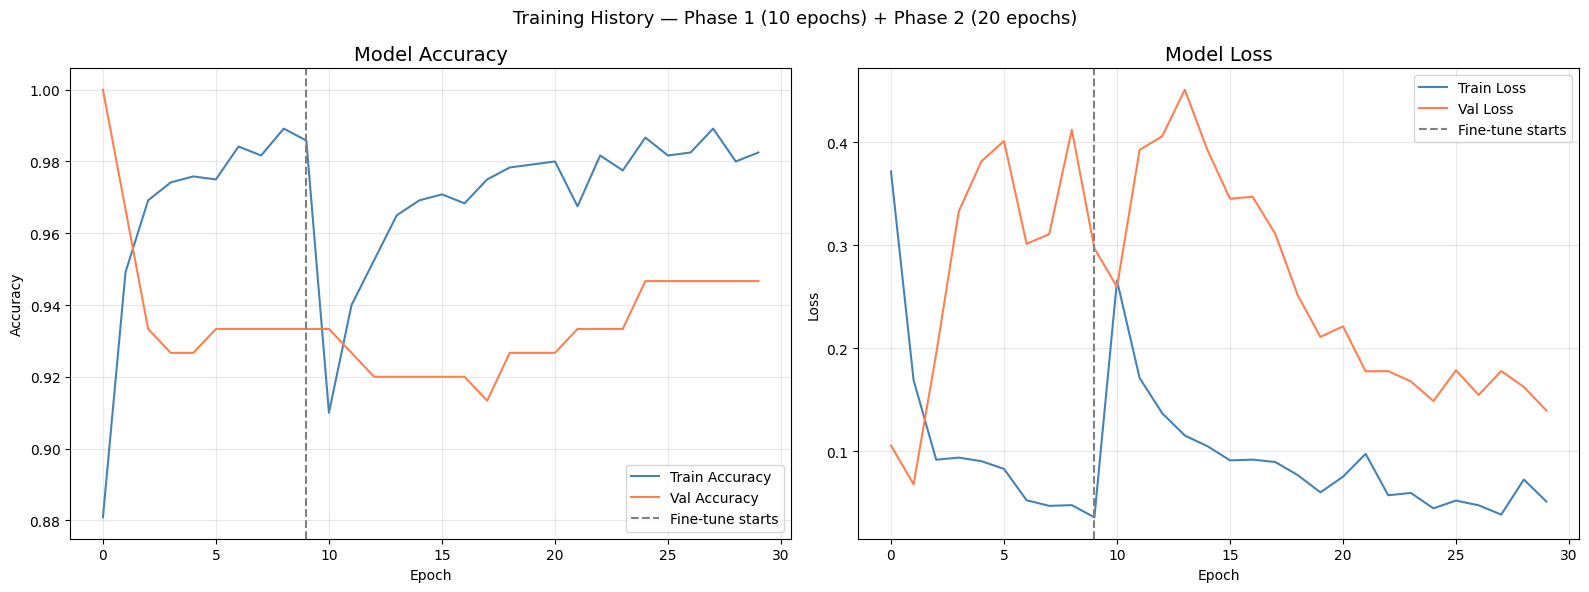

Training curve saved.


In [13]:
def merge_history(h1, h2):
    """Concatenate two Keras History objects."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

combined = merge_history(history_phase1, history_phase2)
phase1_len = len(history_phase1.history['accuracy'])
total_epochs = len(combined['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Accuracy ─────────────────────────────────────────────────────────────────
axes[0].plot(combined['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[0].plot(combined['val_accuracy'], label='Val Accuracy',        color='coral')
axes[0].axvline(phase1_len - 1, color='gray', linestyle='--', label='Fine-tune starts')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[1].plot(combined['loss'],     label='Train Loss',  color='steelblue')
axes[1].plot(combined['val_loss'], label='Val Loss',    color='coral')
axes[1].axvline(phase1_len - 1, color='gray', linestyle='--', label='Fine-tune starts')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Training History — Phase 1 ({phase1_len} epochs) + Phase 2 ({total_epochs - phase1_len} epochs)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curve saved.')

## 🔍 Step 14 — Overfitting & Underfitting Diagnosis

Automatic analysis based on the final epoch metrics.

In [14]:
final_train_acc = combined['accuracy'][-1]
final_val_acc   = combined['val_accuracy'][-1]
final_train_loss = combined['loss'][-1]
final_val_loss   = combined['val_loss'][-1]
gap = final_train_acc - final_val_acc

print('─' * 60)
print(f'  Final Train Accuracy : {final_train_acc:.4f}')
print(f'  Final Val   Accuracy : {final_val_acc:.4f}')
print(f'  Final Train Loss     : {final_train_loss:.4f}')
print(f'  Final Val   Loss     : {final_val_loss:.4f}')
print(f'  Accuracy Gap (Train-Val): {gap:.4f}')
print('─' * 60)

if final_train_acc < 0.70 and final_val_acc < 0.70:
    print('⚠️  UNDERFITTING detected.')
    print('   Both train and val accuracy are low.')
    print('   Suggestions: more epochs, lower dropout, larger model.')
elif gap > 0.12:
    print('⚠️  OVERFITTING detected.')
    print('   Train accuracy >> Val accuracy (gap > 12%).')
    print('   Suggestions: more augmentation, higher dropout, more training data.')
elif final_train_acc > 0.97 and final_val_acc > 0.90:
    print('✅ GOOD FIT — High train & val accuracy, reasonable gap.')
else:
    print('ℹ️  Model is training. Monitor val_loss for convergence.')

────────────────────────────────────────────────────────────
  Final Train Accuracy : 0.9825
  Final Val   Accuracy : 0.9467
  Final Train Loss     : 0.0513
  Final Val   Loss     : 0.1396
  Accuracy Gap (Train-Val): 0.0358
────────────────────────────────────────────────────────────
✅ GOOD FIT — High train & val accuracy, reasonable gap.


## 💾 Step 15 — Save Final Models

Both `.keras` (TF SavedModel format, recommended) and `.h5` are saved.  
The `.keras` format preserves the full preprocessing graph including `Rescaling`.

In [15]:
KERAS_PATH = os.path.join(SAVE_DIR, 'classroom_abnormality_final.keras')
H5_PATH    = os.path.join(SAVE_DIR, 'classroom_abnormality_final.h5')

model.save(KERAS_PATH)
print(f'✅ .keras saved → {KERAS_PATH}')

model.save(H5_PATH)
print(f'✅ .h5    saved → {H5_PATH}')

✅ .keras saved → /content/drive/MyDrive/DeepLearningProject/saved_models/classroom_abnormality_final.keras
✅ .h5    saved → /content/drive/MyDrive/DeepLearningProject/saved_models/classroom_abnormality_final.h5


## 🧪 Step 16 — Evaluate on Test Set

The test set is used **only once**, at the very end.  
Never use test set results to tune hyperparameters — that would cause data leakage.

In [16]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test Loss     : {test_loss:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9600 - loss: 0.0782

Test Accuracy : 0.9600 (96.00%)
Test Loss     : 0.0782


## 📊 Step 17 — Confusion Matrix & Classification Report

The confusion matrix shows **which classes are being confused**.  
The classification report gives per-class Precision, Recall, and F1-Score.

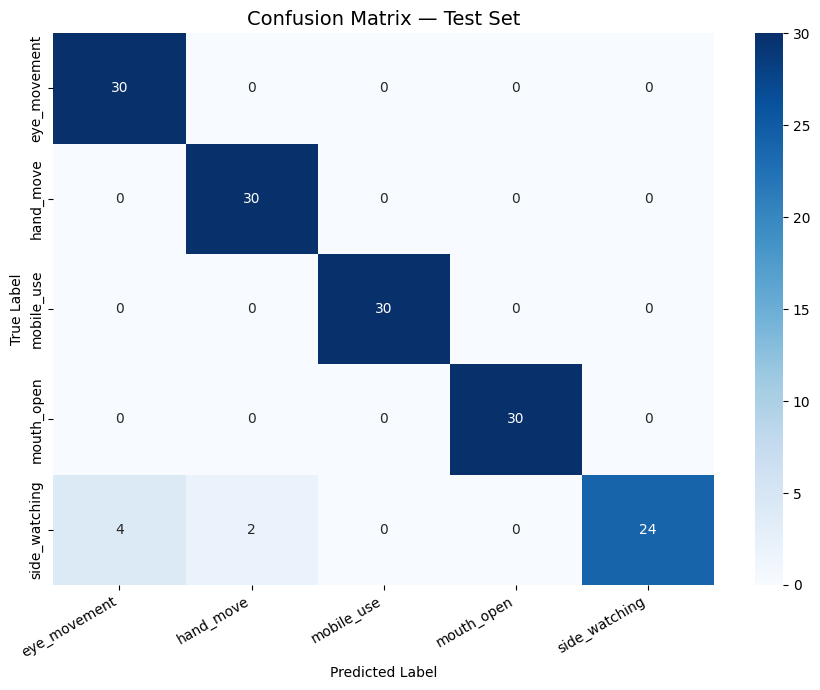

Classification Report:
               precision    recall  f1-score   support

 eye_movement       0.88      1.00      0.94        30
    hand_move       0.94      1.00      0.97        30
   mobile_use       1.00      1.00      1.00        30
   mouth_open       1.00      1.00      1.00        30
side_watching       1.00      0.80      0.89        30

     accuracy                           0.96       150
    macro avg       0.96      0.96      0.96       150
 weighted avg       0.96      0.96      0.96       150



In [17]:
# ── Collect all test predictions ─────────────────────────────────────────────
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap='Blues'
)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Classification report ─────────────────────────────────────────────────────
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

## 📐 Step 18 — Per-Class Precision, Recall, F1 Bar Charts

Visual comparison of metrics across all 5 classes.

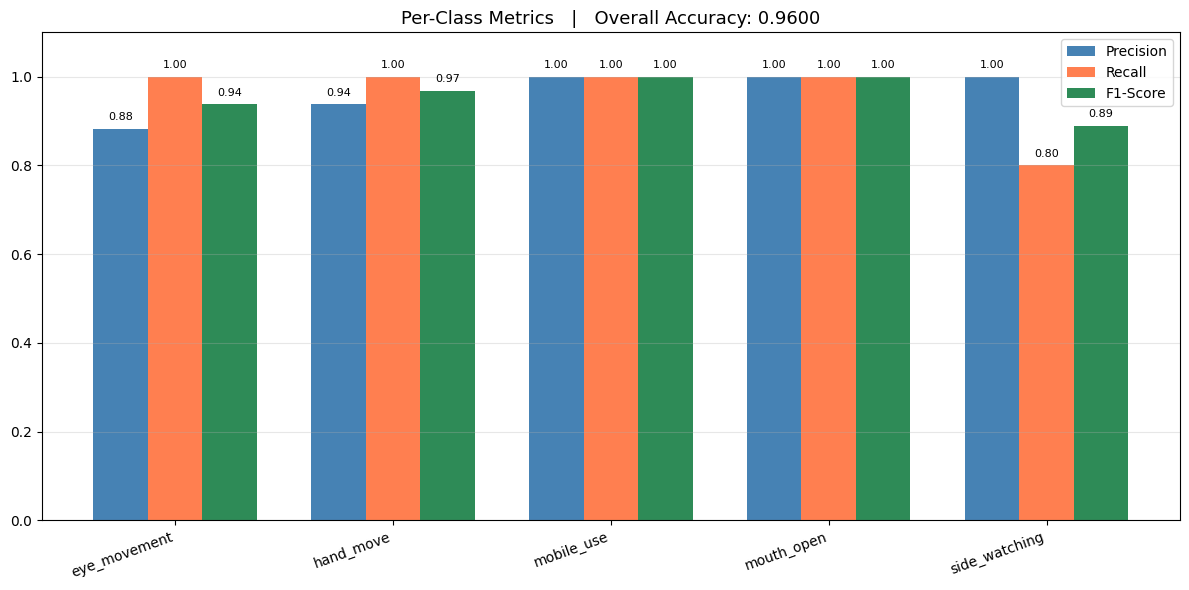

Overall Accuracy  : 0.9600
Macro Precision   : 0.9640
Macro Recall      : 0.9600
Macro F1          : 0.9588


In [18]:
prec   = precision_score(y_true, y_pred, average=None)
rec    = recall_score(y_true, y_pred, average=None)
f1     = f1_score(y_true, y_pred, average=None)
acc_overall = accuracy_score(y_true, y_pred)

x = np.arange(len(CLASS_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, prec, width, label='Precision', color='steelblue')
ax.bar(x,         rec,  width, label='Recall',    color='coral')
ax.bar(x + width, f1,   width, label='F1-Score',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title(f'Per-Class Metrics   |   Overall Accuracy: {acc_overall:.4f}', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i in range(len(CLASS_NAMES)):
    ax.text(x[i]-width, prec[i]+0.02, f'{prec[i]:.2f}', ha='center', fontsize=8)
    ax.text(x[i],       rec[i]+0.02,  f'{rec[i]:.2f}',  ha='center', fontsize=8)
    ax.text(x[i]+width, f1[i]+0.02,   f'{f1[i]:.2f}',   ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall Accuracy  : {acc_overall:.4f}')
print(f'Macro Precision   : {prec.mean():.4f}')
print(f'Macro Recall      : {rec.mean():.4f}')
print(f'Macro F1          : {f1.mean():.4f}')

## 🔥 Step 19 — Grad-CAM Explainability

**Grad-CAM** (Gradient-weighted Class Activation Mapping) highlights  
the image regions that were most important for the model's decision.

This is critical for:
- Verifying the model looks at *the right regions* (face/hands, not background)
- Debugging misclassifications
- Meeting explainability requirements for academic submissions

ValueError: No such layer: out_relu. Existing layers are: ['input_image', 'rescaling', 'mobilenetv2_1.00_224', 'gap', 'head_bn', 'dense_256', 'dropout_1', 'dense_128', 'dropout_2', 'output'].

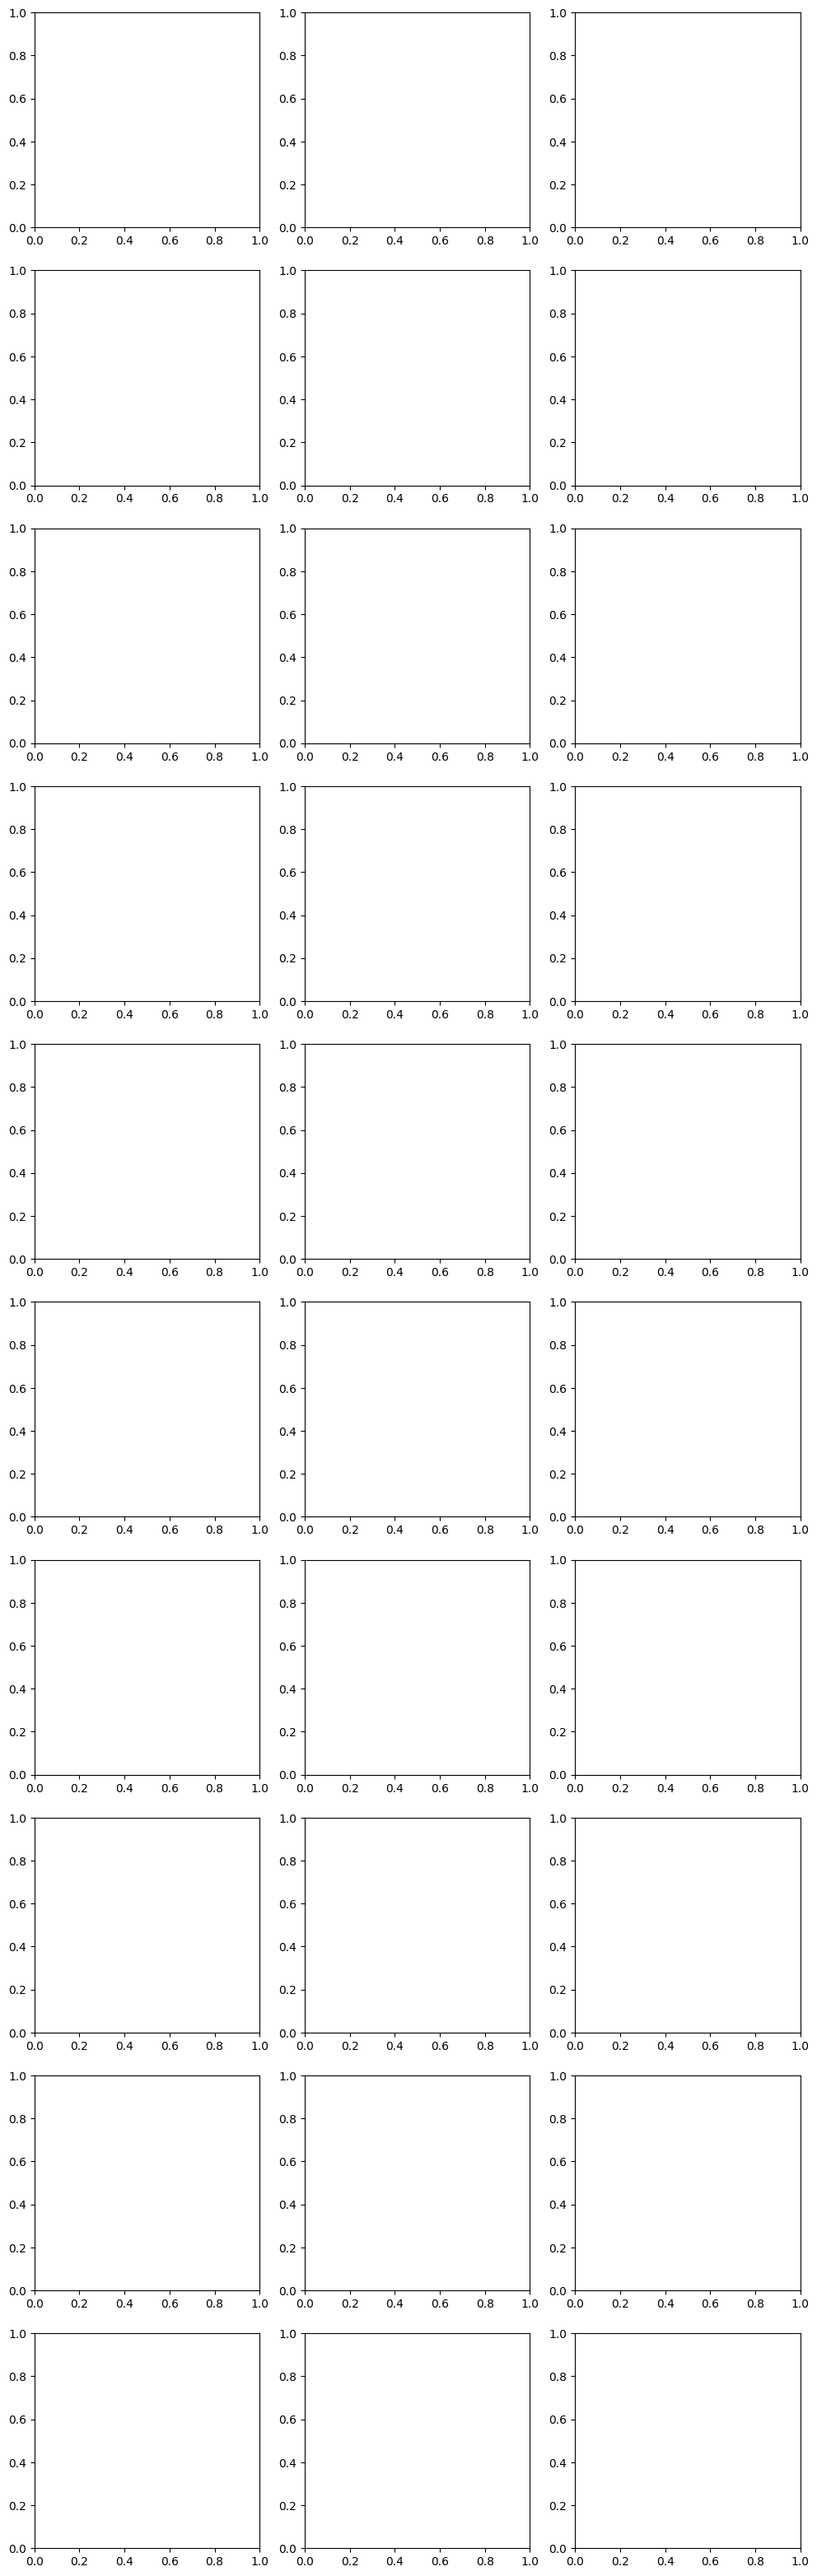

In [20]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Compute Grad-CAM heatmap for an image.
    img_array: numpy array, shape (1, H, W, 3), raw pixel values 0-255.
    """
    grad_model = keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_array_raw, heatmap, alpha=0.45):
    """Overlay the heatmap on the original image."""
    img = img_array_raw[0].astype('uint8')
    heatmap_resized = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = keras_image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras_image.img_to_array(jet_heatmap)
    superimposed = jet_heatmap * alpha + img
    superimposed = np.clip(superimposed, 0, 255).astype('uint8')
    return img, superimposed

# ── Find the last conv layer name in MobileNetV2 ──────────────────────────────
LAST_CONV = 'out_relu'   # last activation in MobileNetV2 before GAP

# ── Run Grad-CAM on test samples ──────────────────────────────────────────────
n_samples = 10
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
sample_count = 0

for images, labels in test_ds:
    for i in range(len(images)):
        if sample_count >= n_samples:
            break
        img_raw = images[i].numpy()[np.newaxis]   # shape (1, 224, 224, 3)
        preds = model.predict(img_raw, verbose=0)[0]
        pred_idx  = np.argmax(preds)
        true_idx  = labels[i].numpy()
        heatmap   = make_gradcam_heatmap(img_raw, model, LAST_CONV, pred_idx)
        orig, overlay = overlay_gradcam(img_raw, heatmap)
        correct = '✅' if pred_idx == true_idx else '❌'

        axes[sample_count, 0].imshow(orig)
        axes[sample_count, 0].set_title(f'Original\nTrue: {CLASS_NAMES[true_idx]}', fontsize=9)
        axes[sample_count, 0].axis('off')

        axes[sample_count, 1].imshow(overlay)
        axes[sample_count, 1].set_title('Grad-CAM Overlay', fontsize=9)
        axes[sample_count, 1].axis('off')

        axes[sample_count, 2].bar(CLASS_NAMES, preds, color=['seagreen' if j==pred_idx else 'lightgray' for j in range(5)])
        axes[sample_count, 2].set_ylim(0, 1)
        axes[sample_count, 2].set_title(f'{correct} Pred: {CLASS_NAMES[pred_idx]} ({preds[pred_idx]*100:.1f}%)', fontsize=9)
        axes[sample_count, 2].tick_params(axis='x', rotation=30)
        sample_count += 1
    if sample_count >= n_samples:
        break

plt.suptitle('Grad-CAM Visualizations — Test Set', fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gradcam.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Grad-CAM visualization saved.')

## 🔮 Step 20 — Single Image Prediction (Upload Any Image)

**How this avoids all preprocessing bugs:**
- Model is reloaded fresh from `.keras` file
- Class names are loaded from `class_names.json` — never hardcoded
- Image is passed as **raw 0–255 pixels** — the `Rescaling` layer inside the model handles normalization
- Top-5 probabilities are displayed as a bar chart
- Grad-CAM is run automatically on the uploaded image

Model loaded. Classes: ['eye_movement', 'hand_move', 'mobile_use', 'mouth_open', 'side_watching']


Saving satu-Senario_12 622.jpg.jpg to satu-Senario_12 622.jpg.jpg


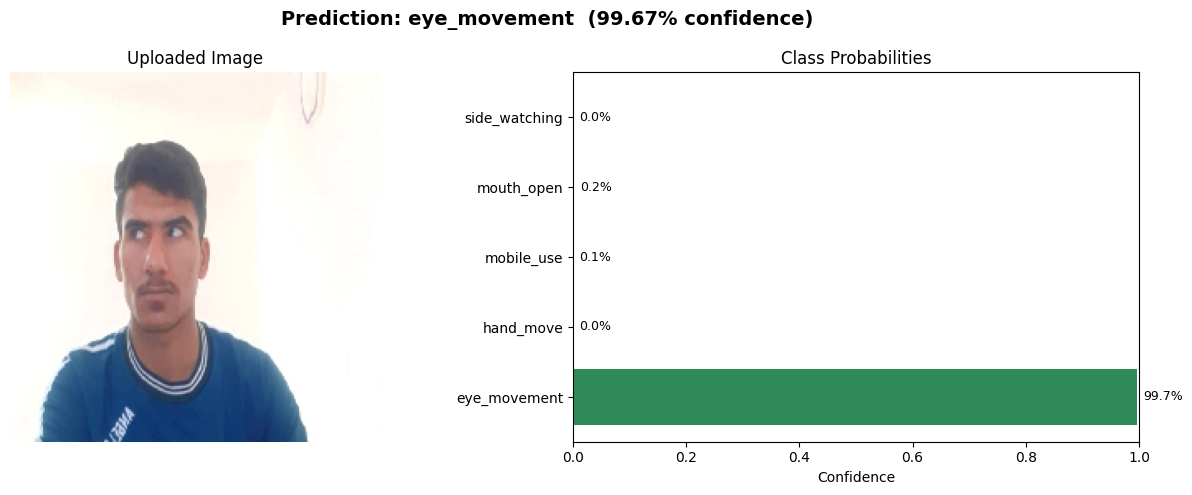


Top-5 Predictions:
───────────────────────────────────
  1. eye_movement         99.67%
  2. mouth_open           0.18%
  3. mobile_use           0.13%
  4. hand_move            0.01%
  5. side_watching        0.00%


AttributeError: 'ReLU' object has no attribute 'output_shape'

In [24]:
# ── Reload model and class names ──────────────────────────────────────────────
from google.colab import files as colab_files
import json, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
from tensorflow.keras.preprocessing import image as keras_image
import tensorflow as tf
from tensorflow import keras

MODEL_PATH   = os.path.join(SAVE_DIR, 'classroom_abnormality_final.keras')
CLASSES_PATH = os.path.join(SAVE_DIR, 'class_names.json')

predict_model = keras.models.load_model(MODEL_PATH)
with open(CLASSES_PATH) as f:
    predict_classes = json.load(f)
print(f'Model loaded. Classes: {predict_classes}')

# ── Upload & preprocess ────────────────────────────────────────────────────────
uploaded  = colab_files.upload()
img_path  = list(uploaded.keys())[0]
pil_img   = keras_image.load_img(img_path, target_size=(224, 224))
img_array = keras_image.img_to_array(pil_img)   # float32, 0–255, no /255
img_batch = np.expand_dims(img_array, axis=0)   # (1,224,224,3)

# ── Predict ────────────────────────────────────────────────────────────────────
probs    = predict_model.predict(img_batch, verbose=0)[0]
top5_idx = np.argsort(probs)[::-1]

# ── Show image + bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(pil_img); axes[0].axis('off'); axes[0].set_title('Uploaded Image', fontsize=12)
colors = ['seagreen' if i == top5_idx[0] else 'lightgray' for i in range(len(predict_classes))]
axes[1].barh(predict_classes, probs, color=colors)
axes[1].set_xlim(0, 1); axes[1].set_xlabel('Confidence'); axes[1].set_title('Class Probabilities', fontsize=12)
for i, p in enumerate(probs):
    axes[1].text(p + 0.01, i, f'{p*100:.1f}%', va='center', fontsize=9)
plt.suptitle(f'Prediction: {predict_classes[top5_idx[0]]}  ({probs[top5_idx[0]]*100:.2f}% confidence)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTop-5 Predictions:')
print('─' * 35)
for rank, idx in enumerate(top5_idx, 1):
    print(f'  {rank}. {predict_classes[idx]:<20} {probs[idx]*100:.2f}%')

# ── Grad-CAM ───────────────────────────────────────────────────────────────────
# FIX: the backbone is a NESTED sub-model inside predict_model.
# outer_model.get_layer() only sees the top-level list — 'out_relu' and
# 'mobilenetv2_1.00_224/Conv_1' are both invisible from there.
# Solution: extract the backbone sub-model first, then call get_layer() on IT.

def find_backbone(outer_model):
    """Return the first nested keras.Model layer (the MobileNetV2 sub-model)."""
    for layer in outer_model.layers:
        if isinstance(layer, keras.Model):
            return layer
    raise ValueError("No nested backbone sub-model found.")

def find_last_conv_layer(backbone):
    """
    Walk backbone layers in reverse, return the name of the last one
    whose output is a 4-D feature map (batch, H, W, C).
    """
    for layer in reversed(backbone.layers):
        if len(layer.output_shape) == 4:
            return layer.name
    raise ValueError("No 4-D conv layer found in backbone.")

def make_gradcam_heatmap_fixed(img_batch, outer_model, pred_index):
    """
    Grad-CAM that correctly handles a nested backbone sub-model.

    img_batch   : np.ndarray (1, 224, 224, 3), raw 0-255 pixels.
    outer_model : the full wrapper model (includes Rescaling layer).
    pred_index  : integer class index to explain.
    """
    backbone       = find_backbone(outer_model)
    last_conv_name = find_last_conv_layer(backbone)
    print(f'  Grad-CAM layer: backbone → "{last_conv_name}"')

    # Sub-graph: backbone.input → [last_conv_output, backbone_output]
    backbone_grad = keras.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(last_conv_name).output, backbone.output]
    )

    # Apply the Rescaling layer from outer_model so backbone gets 0-1 input
    rescaling   = outer_model.get_layer('rescaling')
    img_tensor  = tf.cast(img_batch, tf.float32)
    img_rescaled = rescaling(img_tensor)

    with tf.GradientTape() as tape:
        conv_outputs, backbone_out = backbone_grad(img_rescaled)
        tape.watch(conv_outputs)

        # Run the custom head layer-by-layer
        x = outer_model.get_layer('gap')(backbone_out)
        x = outer_model.get_layer('head_bn')(x)
        x = outer_model.get_layer('dense_256')(x)
        x = outer_model.get_layer('dropout_1')(x, training=False)
        x = outer_model.get_layer('dense_128')(x)
        x = outer_model.get_layer('dropout_2')(x, training=False)
        predictions = outer_model.get_layer('output')(x)

        class_score = predictions[:, pred_index]

    grads       = tape.gradient(class_score, conv_outputs)
    pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))       # (C,)
    conv_out    = conv_outputs[0]                              # (H, W, C)
    heatmap     = conv_out @ pooled[..., tf.newaxis]           # (H, W, 1)
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.maximum(heatmap, 0)
    heatmap     = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_batch_raw, heatmap, alpha=0.45):
    img          = img_batch_raw[0].astype('uint8')
    jet_colors   = cm.get_cmap('jet')(np.arange(256))[:, :3]
    jet_heatmap  = jet_colors[np.uint8(255 * heatmap)]
    jet_img      = keras_image.array_to_img(jet_heatmap)
    jet_img      = jet_img.resize((img.shape[1], img.shape[0]))
    jet_heatmap  = keras_image.img_to_array(jet_img)
    superimposed = np.clip(jet_heatmap * alpha + img, 0, 255).astype('uint8')
    return img, superimposed

heatmap            = make_gradcam_heatmap_fixed(img_batch, predict_model, top5_idx[0])
orig, gcam_overlay = overlay_gradcam(img_batch, heatmap)

fig2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
ax2[0].imshow(orig);         ax2[0].set_title('Original');                 ax2[0].axis('off')
ax2[1].imshow(gcam_overlay); ax2[1].set_title('Grad-CAM — Model Focus Area'); ax2[1].axis('off')
plt.suptitle(f'Grad-CAM for predicted class: {predict_classes[top5_idx[0]]}', fontsize=13)
plt.tight_layout()
plt.show()

## ⬇️ Step 21 — Download Model Files to Local Machine

In [25]:
from google.colab import files as colab_files

# Download .keras
colab_files.download(os.path.join(SAVE_DIR, 'classroom_abnormality_final.keras'))

# Download .h5
colab_files.download(os.path.join(SAVE_DIR, 'classroom_abnormality_final.h5'))

# Download class names
colab_files.download(os.path.join(SAVE_DIR, 'class_names.json'))

print('Downloads initiated.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads initiated.


## ✅ Step 22 — Summary & Next Steps

### What this notebook implements
| Feature | Status |
|---|---|
| MobileNetV2 transfer learning | ✅ |
| Rescaling inside model (no double-norm bug) | ✅ |
| Class names from folders (no hardcoding) | ✅ |
| Strong augmentation (6 transforms) | ✅ |
| EarlyStopping | ✅ |
| ReduceLROnPlateau | ✅ |
| ModelCheckpoint (best val_loss) | ✅ |
| Phase 1: Frozen backbone | ✅ |
| Phase 2: Fine-tuning top-30 layers | ✅ |
| Overfitting / underfitting detection | ✅ |
| Confusion matrix | ✅ |
| Classification report | ✅ |
| Per-class Precision / Recall / F1 | ✅ |
| Training curves (both phases) | ✅ |
| Grad-CAM visualization | ✅ |
| Top-5 prediction with bar chart | ✅ |
| .keras + .h5 model export | ✅ |
| class_names.json export | ✅ |